The goal here is to scrape some runway image archives from different seasons in the past, use a claude API to analyze the images and save them into a df, use that saved analysis to forecast the next seasons, and finally use an OpenAI API to actually generate images from the forecast descriptions.

In [3]:
import anthropic
import base64
import os
import pandas as pd
from pathlib import Path
import time
import json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [4]:

# reading the API key from file
with open("fashionAPI.txt", "r") as f:
    api_key = f.read().strip()  # .strip() removes any extra spaces/newlines

client = anthropic.Anthropic(api_key=api_key)

# checking to see if it works
message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Say hello and confirm you're working!"}
    ]
)

print(message.content[0].text)


Hello! 👋 Yes, I'm working and ready to help! I'm Claude, an AI assistant made by Anthropic. What can I do for you today?


In [5]:
%%writefile .gitignore
fashionAPI.txt
image-gen-API.txt
__pycache__/
*.pyc
.DS_Store
.ipynb_checkpoints/
data/

Overwriting .gitignore


In [6]:
#Before I run a massive amount of pictures, I am using this chunk to test out what I want my prompts to be using only one image.
# Read your first fashion image
with open("data/exampleML.jpg", "rb") as image_file:
    image_data = base64.b64encode(image_file.read()).decode("utf-8")

# Analyze it
message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": "image/jpeg",
                        "data": image_data,
                    },
                },
                {
                    "type": "text",
                    "text": """Analyze this fashion image and provide:
                    1. Dominant colors (list 2-3 main colors)
                    2. Silhouette type (e.g., oversized, fitted, A-line, etc.)
                    3. Key garment types (e.g., blazer, dress, pants)
                    4. Fabric textures (e.g., silk, denim, knit)
                    5. Notable styling elements (accessories, layering, etc.)
                    6. Patterns (polka dots, stripes, solids, florals, etc.)
                    7. Overall aesthetic/vibe (e.g., minimalist, avant-garde, streetwear)
                    
                    Format your response clearly with labeled sections."""
                }
            ],
        }
    ],
)

print(message.content[0].text)

# Fashion Analysis

## 1. Dominant Colors
- **Cream/Off-White**
- **Black**
- **Purple & Neon Green** (accent colors)

## 2. Silhouette Type
**Oversized/Relaxed** with **tapered/fitted bottoms**
- Loose, slouchy outerwear contrasts with sleek, fitted lower half

## 3. Key Garment Types
- Oversized button-up jacket/shirt jacket (cream)
- Black cargo/technical pants with multiple zippers
- Purple waistband/underlayer visible at waist
- Black studded boots

## 4. Fabric Textures
- **Nylon/technical fabric** (jacket - appears water-resistant)
- **Leather or faux leather** (pants - glossy finish)
- **Knit/ribbed** (waistband)
- **Studded metal embellishments** (boots)

## 5. Notable Styling Elements
- **Chain necklace** with pendant (gold-toned)
- **Pearl chain necklace** (layered)
- **Neon green gloves** (matching accent color)
- **Oversized sunglasses** (dark lenses, contemporary style)
- **Statement belt** with buckle detail
- **Silver jewelry** throughout

## 6. Patterns
- **Solids only

Now that we know the API key can accurately analyze the image, we can find and use a dataset so we can analyze trends through seasons, years, etc

In [8]:
import os
print(os.getcwd())

/Users/eilymacritchie/Desktop/MQE/ML project


In [9]:
from pathlib import Path
print(list(Path("data").iterdir()))

[PosixPath('data/ss_2026'), PosixPath('data/fw_2026'), PosixPath('data/ss_2025'), PosixPath('data/ss_2023'), PosixPath('data/ss_2024'), PosixPath('data/fw_2023'), PosixPath('data/.ipynb_checkpoints'), PosixPath('data/fw_2024'), PosixPath('data/fw_2025'), PosixPath('data/exampleML.jpg')]


In [10]:
#Now I compiled a dataset of Valentino's runway looks from the past 8 seasons. 
#I will use the prompts I decided on after testing them above to compile analysis from all 8 season folders into a df.
from PIL import Image
import io

def analyze_fashion_image(image_path):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1568, 1568))
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=85)
        image_data = base64.b64encode(buffer.getvalue()).decode("utf-8")

    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/jpeg",
                            "data": image_data,
                        },
                    },
                    {
                        "type": "text",
                        "text": """Analyze this fashion runway look. Return your response as valid JSON with this exact structure:
                        {
                            "colors": ["color1", "color2", "color3"],
                            "silhouette": "type here",
                            "garments": ["garment1", "garment2"],
                            "fabrics": ["fabric1", "fabric2"],
                            "patterns": "pattern type or none",
                            "aesthetic": "style here"
                        }
                        
                        Return only the raw JSON with no markdown formatting, no code blocks, no backticks, and no other text."""
                    }
                ],
            }
        ],
    )
    
    return message.content[0].text
 
def parse_response(raw_text):
    """BUG FIX 2: Strip markdown fences before parsing JSON"""
    cleaned = raw_text.strip()
    # Remove ```json ... ``` or ``` ... ``` wrappers if present
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1]          # grab content after first ```
        if cleaned.startswith("json"):
            cleaned = cleaned[4:]                  # strip the word "json"
    cleaned = cleaned.strip()
    return json.loads(cleaned)
 

# Process each image
seasons = {
    "fw_2023": "data/fw_2023",
    "ss_2024": "data/ss_2024",
    "fw_2024": "data/fw_2024",
    "ss_2025": "data/ss_2025",
    "fw_2025": "data/fw_2025",
    "ss_2026": "data/ss_2026",
    "fw_2026": "data/fw_2026",
    "ss_2023": "data/ss_2023",
}
results = []
success_count = 0

for season, folder in seasons.items():
    image_files = list(Path(folder).glob("*.jpg")) + \
                  list(Path(folder).glob("*.jpeg")) + \
                  list(Path(folder).glob("*.png")) + \
                  list(Path(folder).glob("*.webp"))
    
    print(f"\n--- {season}: found {len(image_files)} images ---")
    
    for i, img_path in enumerate(image_files):
        print(f"Processing {i+1}/{len(image_files)}: {img_path.name}")
        
        try:
            raw_response = analyze_fashion_image(img_path)
            analysis = parse_response(raw_response)
            
            results.append({
                'filename':   img_path.name,
                'season':     season,
                'designer':   'Valentino',
                'colors':     ', '.join(analysis.get('colors', [])),
                'silhouette': analysis.get('silhouette'),
                'garments':   ', '.join(analysis.get('garments', [])),
                'fabrics':    ', '.join(analysis.get('fabrics', [])),
                'patterns':   analysis.get('patterns'),
                'aesthetic':  analysis.get('aesthetic')
            })
            
            success_count += 1
            print(f"✓ Colors: {analysis.get('colors')} | Silhouette: {analysis.get('silhouette')}")
            
        except json.JSONDecodeError as e:
            print(f"✗ JSON Parse Error: {e}")
            print(f"  Raw response was: {raw_response[:150]}")
            results.append({
                'filename': img_path.name, 'season': season, 'designer': 'Valentino',
                'colors': None, 'silhouette': None, 'garments': None,
                'fabrics': None, 'patterns': None, 'aesthetic': f"ERROR: {e}"
            })
            
        except Exception as e:
            print(f"✗ Error: {e}")
            results.append({
                'filename': img_path.name, 'season': season, 'designer': 'Valentino',
                'colors': None, 'silhouette': None, 'garments': None,
                'fabrics': None, 'patterns': None, 'aesthetic': f"ERROR: {e}"
            })
        
        time.sleep(1)

df = pd.DataFrame(results)
df.to_csv('valentino_analysis_results.csv', index=False)

print(f"\n✓ Analysis complete! Results saved to valentino_analysis_results.csv")
print(f"Successfully analyzed {success_count} images")


--- fw_2023: found 73 images ---
Processing 1/73: Valentino-Fall-Winter-2023-Fashion34.webp
✓ Colors: ['black', 'multicolor', 'silver', 'pastels'] | Silhouette: fitted halter top with flared embellished skirt
Processing 2/73: Valentino-Fall-Winter-2023-Fashion63.webp
✓ Colors: ['black', 'red', 'white'] | Silhouette: oversized, relaxed fit with straight lines
Processing 3/73: Valentino-Fall-Winter-2023-Fashion22.webp
✓ Colors: ['black', 'white'] | Silhouette: oversized tailored with dramatic length
Processing 4/73: Valentino-Fall-Winter-2023-Fashion59.webp
✓ Colors: ['black', 'yellow', 'brown'] | Silhouette: oversized blazer with structured shoulders
Processing 5/73: Valentino-Fall-Winter-2023-Fashion18.webp
✓ Colors: ['black', 'charcoal', 'silver', 'metallic'] | Silhouette: flowing cape silhouette with fitted bodice and dramatic train
Processing 6/73: Valentino-Fall-Winter-2023-Fashion38.webp
✓ Colors: ['black', 'white', 'gray'] | Silhouette: oversized, dramatic, avant-garde
Processin

In [11]:
df = pd.read_csv('valentino_analysis_results.csv')

df.head()

,filename,season,designer,colors,silhouette,garments,fabrics,patterns,aesthetic
0,Valentino-Fall-Winter-2023-Fashion34.webp,fw_2023,Valentino,"black, multicolor, silver, pastels",fitted halter top with flared embellished skirt,"halter dress, embellished skirt, lace-up boots","jersey, sequin, crystal embellishment, leather",floral embellishment gradient,haute couture evening wear with edgy rock elem...
1,Valentino-Fall-Winter-2023-Fashion63.webp,fw_2023,Valentino,"black, red, white","oversized, relaxed fit with straight lines","black button-up shirt, red v-neck shirt, black...","cotton, wool blend, leather",none,contemporary minimalist with edgy accessories
2,Valentino-Fall-Winter-2023-Fashion22.webp,fw_2023,Valentino,"black, white",oversized tailored with dramatic length,"long black coat, white dress shirt, black tie,...","wool, cotton, leather, feather trim",studded detail on sleeve,high fashion punk rock androgynous
3,Valentino-Fall-Winter-2023-Fashion59.webp,fw_2023,Valentino,"black, yellow, brown",oversized blazer with structured shoulders,"oversized black blazer, black mini dress, blac...","wool, silk, leather, patent leather",none,modern minimalist with edgy elegance
4,Valentino-Fall-Winter-2023-Fashion18.webp,fw_2023,Valentino,"black, charcoal, silver, metallic",flowing cape silhouette with fitted bodice and...,"embellished cape, black feathered mini dress, ...","tulle, sheer mesh, feathers, suede, sequined m...",all-over crystal and rhinestone embellishment,haute couture gothic glamour with dramatic eve...


Yay now I have a dataset of fashion from different seasons over the last 4 years. I kept to one designer (Valentino) to intentionally be able to separate out what is truly a trend, as opposed to just a fashion house or a designor's 'shtick'. The next step here is to move onto attempting to forcast what a look would be from Valentino in the coming seasons: Spring Summer 2027 and Fall Winter 2027.

In [13]:

#getting an idea first of what I'm working with before deciding forecasting method
df = pd.read_csv('valentino_analysis_results.csv')

# Define season order chronologically
season_order = ['fw_2023', 'ss_2024', 'fw_2024', 'ss_2025', 'fw_2025', 'ss_2026', 'fw_2026']

# Frequency of each value per season for a given column
def top_values_by_season(df, column, top_n=5):
    results = {}
    for season in season_order:
        subset = df[df['season'] == season][column].dropna()
        # Each row may have comma-separated values, so split them out
        all_values = [v.strip() for cell in subset for v in str(cell).split(',')]
        results[season] = Counter(all_values).most_common(top_n)
    return results

color_trends = top_values_by_season(df, 'colors')
silhouette_trends = top_values_by_season(df, 'silhouette')
aesthetic_trends = top_values_by_season(df, 'aesthetic')

for season in season_order:
    print(f"\n{season}")
    print(f"  Top colors:     {color_trends[season]}")
    print(f"  Top silhouette: {silhouette_trends[season]}")
    print(f"  Top aesthetic:  {aesthetic_trends[season]}")


fw_2023
  Top colors:     [('black', 72), ('white', 63), ('red', 13), ('cream', 11), ('gray', 6)]
  Top silhouette: [('oversized', 16), ('oversized blazer with shorts', 5), ('elongated', 4), ('flowing', 4), ('dramatic', 3)]
  Top aesthetic:  [('high fashion', 16), ('avant-garde', 13), ('androgynous', 7), ('contemporary high fashion', 6), ('contemporary luxury', 4)]

ss_2024
  Top colors:     [('white', 38), ('cream', 33), ('black', 20), ('gold', 13), ('beige', 11)]
  Top silhouette: [('flowing', 9), ('fitted', 6), ('oversized', 5), ('relaxed', 5), ('A-line mini dress', 5)]
  Top aesthetic:  [('modern elegance', 9), ('haute couture', 7), ('minimalist chic', 6), ('minimalist luxury', 6), ('high fashion', 6)]

fw_2024
  Top colors:     [('black', 64), ('nude', 13), ('gold', 10), ('charcoal', 5), ('brown', 5)]
  Top silhouette: [('A-line', 7), ('oversized', 5), ('fitted', 4), ('tailored', 3), ('structured', 3)]
  Top aesthetic:  [('haute couture', 30), ('minimalist luxury', 13), ('modern 

The data is clean and came out as expected. I am going to do two forecasting methods and compare them: first I will continue using my Claude API and use that to forecast, and second I will do a more "manual" statistical forecast. I will then compare the two and still be able to feed both data results back into claude afterwards to generate images of predicted looks that Valentino will design in the coming seasons. 

In [15]:
#Starting with the Claude API forecast
# Build trend summary
trend_summary = ""
for season in season_order:
    trend_summary += f"\n{season}:\n"
    trend_summary += f"  Colors: {color_trends[season]}\n"
    trend_summary += f"  Silhouettes: {silhouette_trends[season]}\n"
    trend_summary += f"  Aesthetics: {aesthetic_trends[season]}\n"

# Send to Claude for forecast
forecast_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=1500,
    messages=[
        {
            "role": "user",
            "content": f"""You are an expert fashion trend forecaster specializing in luxury haute couture.
Below is a quantitative analysis of Valentino's runway collections from fw_2023 through fw_2026,
showing the most frequent colors, silhouettes, and aesthetics per season.

{trend_summary}

Based on these trends, forecast what Valentino's ss_2027 collection will look like.
Pay close attention to patterns that appear specifically in past SS seasons versus FW seasons,
and weight your prediction accordingly.

Provide a detailed prediction covering:
- Colors (dominant palette and any emerging accent colors)
- Silhouette direction
- Key garments
- Fabrics and textures
- Patterns
- Overall aesthetic"""
        }
    ]
)

claude_forecast = forecast_message.content[0].text
print(claude_forecast)

# Valentino SS_2027 Collection Forecast

## Color Palette Prediction

**Dominant Colors:**
- **Black** (55-65 instances): Despite being traditionally lighter in SS seasons, black has intensified across Valentino's recent collections, appearing prominently even in SS_2024 (20), SS_2025 (69), and SS_2026 (58). This represents a strategic shift toward year-round sophistication.
- **Cream/Ivory** (35-42 instances): The house code of cream shows strong SS consistency (SS_2024: 33, SS_2025: 46, SS_2026: 20).
- **Gold** (32-38 instances): Metallic gold has emerged as a signature accent, escalating from 13 in SS_2024 to 43 in SS_2025 and 29 in SS_2026.

**Secondary/Accent Colors:**
- **White** (22-28 instances): Classic SS staple, though decreasing from SS_2024's dominance
- **Red** (18-24 instances): Valentino's signature red resurfaces in SS collections but more selectively than FW
- **Silver** (12-16 instances): Emerging metallic to complement gold (introduced SS_2026 with 14)
- **Beige/Tau

In [16]:
#now I am doing a statistical forecast so it can be compared against claude's forecast:

# Separate SS and FW seasons
ss_seasons = ['ss_2023', 'ss_2024', 'ss_2025', 'ss_2026']
fw_seasons = ['fw_2023', 'fw_2024', 'fw_2025', 'fw_2026']

# Weight recent seasons more heavily (most recent = highest weight)
# ss_2023 = 1, ss_2024 = 2, ss_2025 = 3, ss_2026 = 4
ss_weights = {season: i+1 for i, season in enumerate(ss_seasons)}

def weighted_top_values(df, seasons, weights, column, top_n=5):
    """For each unique value, compute its weighted frequency share across seasons"""
    value_scores = Counter()
    
    for season in seasons:
        subset = df[df['season'] == season][column].dropna()
        all_values = [v.strip() for cell in subset for v in str(cell).split(',')]
        total = len(all_values) if all_values else 1
        counts = Counter(all_values)
        
        # Weight each value's share by the season's recency weight
        for value, count in counts.items():
            value_scores[value] += (count / total) * weights[season]
    
    return value_scores.most_common(top_n)

def linear_trend_top_values(df, seasons, column, top_n=5):
    """Fit a linear trend to each value's frequency share across seasons,
    project forward one season, return top predicted values"""
    # Get all unique values across SS seasons
    all_values = set()
    season_totals = {}
    season_counts = {}
    
    for season in seasons:
        subset = df[df['season'] == season][column].dropna()
        values = [v.strip() for cell in subset for v in str(cell).split(',')]
        season_totals[season] = len(values) if values else 1
        season_counts[season] = Counter(values)
        all_values.update(values)
    
    # For each value, fit a line across the 4 SS seasons and project to season 5
    predictions = {}
    x = np.array([1, 2, 3, 4])  # ss_2023, ss_2024, ss_2025, ss_2026
    
    for value in all_values:
        y = np.array([
            season_counts[s].get(value, 0) / season_totals[s]
            for s in seasons
        ])
        # Fit linear regression
        slope, intercept = np.polyfit(x, y, 1)
        # Project to x=5 (ss_2027)
        predicted_share = intercept + slope * 5
        predictions[value] = max(predicted_share, 0)  # floor at 0
    
    # Return top predicted values
    return sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Run both methods on SS seasons only
print("=== STATISTICAL FORECAST: ss_2027 ===")
print("(SS seasons only: ss_2023 → ss_2024 → ss_2025 → ss_2026)\n")

print("--- METHOD 1: Weighted Recency Averaging ---")
print("(more recent SS seasons count more)\n")

wr_colors = weighted_top_values(df, ss_seasons, ss_weights, 'colors')
wr_silhouettes = weighted_top_values(df, ss_seasons, ss_weights, 'silhouette')
wr_aesthetics = weighted_top_values(df, ss_seasons, ss_weights, 'aesthetic')

print(f"Predicted colors:     {wr_colors}")
print(f"Predicted silhouette: {wr_silhouettes}")
print(f"Predicted aesthetic:  {wr_aesthetics}")

print("\n--- METHOD 2: Linear Trend Projection ---")
print("(projects the trajectory of each value forward one season)\n")

lt_colors = linear_trend_top_values(df, ss_seasons, 'colors')
lt_silhouettes = linear_trend_top_values(df, ss_seasons, 'silhouette')
lt_aesthetics = linear_trend_top_values(df, ss_seasons, 'aesthetic')

print(f"Predicted colors:     {lt_colors}")
print(f"Predicted silhouette: {lt_silhouettes}")
print(f"Predicted aesthetic:  {lt_aesthetics}")

# Save statistical forecast as a string for image generation later
statistical_forecast = f"""
STATISTICAL FORECAST FOR VALENTINO SS_2027

Method 1 - Weighted Recency:
  Colors: {wr_colors}
  Silhouettes: {wr_silhouettes}
  Aesthetics: {wr_aesthetics}

Method 2 - Linear Trend Projection:
  Colors: {lt_colors}
  Silhouettes: {lt_silhouettes}
  Aesthetics: {lt_aesthetics}
"""
print(statistical_forecast)

=== STATISTICAL FORECAST: ss_2027 ===
(SS seasons only: ss_2023 → ss_2024 → ss_2025 → ss_2026)

--- METHOD 1: Weighted Recency Averaging ---
(more recent SS seasons count more)

Predicted colors:     [('black', 1.8900641988397089), ('cream', 1.1038475130311864), ('gold', 0.983770062137409), ('white', 0.9372627146096534), ('red', 0.5284097535117943)]
Predicted silhouette: [('tailored', 0.5154716880448775), ('flowing', 0.3608028335301062), ('fitted', 0.34834710743801656), ('relaxed', 0.3461065642113408), ('elongated', 0.33288409074233416)]
Predicted aesthetic:  [('haute couture', 0.6331214196283843), ('high fashion', 0.4715464289779306), ('avant-garde', 0.4078579082023135), ('contemporary luxury', 0.37460007210504687), ('modern elegance', 0.24875055298291177)]

--- METHOD 2: Linear Trend Projection ---
(projects the trajectory of each value forward one season)

Predicted colors:     [('black', 0.19103763583355404), ('gold', 0.14086403392525843), ('cream', 0.10114630267691488), ('white', 

Obviously the statistical forecast is harder to digest than the claude one, so before moving onto image generation, I am going to create a chart and a summary cell:


  METHOD 1: Weighted Recency
  Colors:      black, cream, gold, white, red
  Silhouette:  tailored, flowing, fitted, relaxed, elongated
  Aesthetic:   haute couture, high fashion, avant-garde, contemporary luxury, modern elegance

  METHOD 2: Linear Trend Projection
  Colors:      black, gold, cream, white, red
  Silhouette:  tailored, structured, elongated, fitted, straight-leg
  Aesthetic:   haute couture, contemporary luxury, high fashion, modern luxury, vintage-inspired


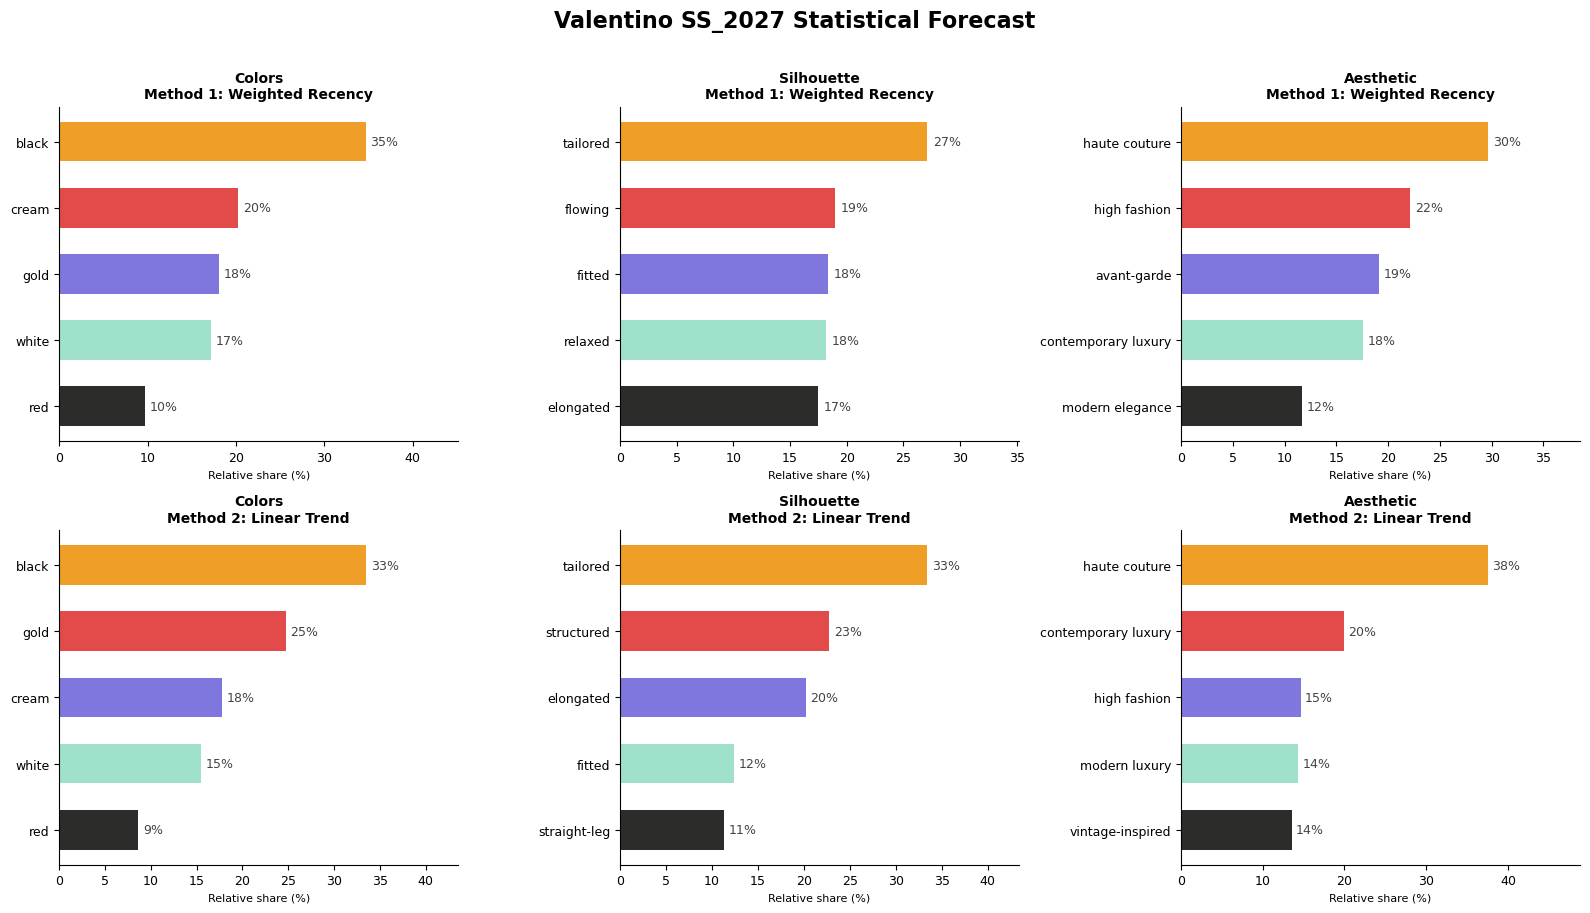

In [49]:
#making statistical forecast easier to manage

#summary first:
def print_clean_forecast(label, colors, silhouettes, aesthetics):
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Colors:      {', '.join([v for v,_ in colors])}")
    print(f"  Silhouette:  {', '.join([v for v,_ in silhouettes])}")
    print(f"  Aesthetic:   {', '.join([v for v,_ in aesthetics])}")

print_clean_forecast("METHOD 1: Weighted Recency", wr_colors, wr_silhouettes, wr_aesthetics)
print_clean_forecast("METHOD 2: Linear Trend Projection", lt_colors, lt_silhouettes, lt_aesthetics)



#now here's a chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Valentino SS_2027 Statistical Forecast", fontsize=16, fontweight='bold', y=1.01)

categories = [
    ("Colors",     wr_colors,     lt_colors),
    ("Silhouette", wr_silhouettes, lt_silhouettes),
    ("Aesthetic",  wr_aesthetics,  lt_aesthetics),
]

method_titles = ["Method 1: Weighted Recency", "Method 2: Linear Trend"]
colors_wr = ["#1a1a1a", "#f5f0e8", "#c9a84c", "#ffffff", "#cc2200"]
bar_colors = ["#2C2C2A", "#9FE1CB", "#7F77DD", "#E24B4A", "#EF9F27"]

for col, (cat_name, wr_data, lt_data) in enumerate(categories):
    for row, (data, title) in enumerate([(wr_data, method_titles[0]), (lt_data, method_titles[1])]):
        ax = axes[row][col]
        labels = [v for v, _ in data]
        values = [s for _, s in data]
        
        # Normalize to percentages for readability
        total = sum(values)
        pcts = [v / total * 100 for v in values]
        
        bars = ax.barh(labels[::-1], pcts[::-1], color=bar_colors[:len(labels)], 
                       edgecolor='none', height=0.6)
        
        # Add percentage labels on bars
        for bar, pct in zip(bars, pcts[::-1]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{pct:.0f}%', va='center', fontsize=9, color='#444')
        
        ax.set_title(f"{cat_name}\n{title}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Relative share (%)", fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=9)
        ax.set_xlim(0, max(pcts) * 1.3)

plt.tight_layout()
plt.savefig('outputs/statistical_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


Time to take both outputs (claude's and the statistical one) and use image generation to predict what a look in Valentino's upcoming spring summer line will look like. Claude doesn't do image generation, so I will be getting another api key from OpenAI to complete this. 

In [20]:
pip install openai

Note: you may need to restart the kernel to use updated packages.


In [21]:
from openai import OpenAI
import requests

# Load OpenAI key
with open("image-gen-API.txt", "r") as f:
    openai_api_key = f.read().strip()

openai_client = OpenAI(api_key=openai_api_key)

# --- STEP 1: Turn both forecasts into image prompts via Claude ---

# Prompt A: from Claude forecast (already narrative, just needs a clean prompt extracted). 
prompt_a_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[{
        "role": "user",
        "content": f"""Based on this fashion forecast for Valentino SS_2027, write a single detailed 
image generation prompt (3-4 sentences) that describes one representative runway look. 
Be specific about garment construction, colors, fabrics, silhouette, styling details, and mood.
Write it as a direct visual description, not as an instruction. Important: The prompt must describe fully clothed looks only. 
Focus on garment construction, tailoring, and fabric details. 
Do not reference exposed skin, bare torsos, or revealing styling. Use the words taupe or beige to describe the color nude.""

Forecast:
{claude_forecast}"""
    }]
)
image_prompt_claude = prompt_a_message.content[0].text
print("=== IMAGE PROMPT FROM CLAUDE FORECAST ===")
print(image_prompt_claude)

# Prompt B: from statistical forecast
stat_summary = f"""
Top predicted colors: {', '.join([v for v,_ in wr_colors])}
Top predicted silhouettes: {', '.join([v for v,_ in wr_silhouettes])}
Top predicted aesthetics: {', '.join([v for v,_ in wr_aesthetics])}
Rising trends (linear projection): 
  colors: {', '.join([v for v,_ in lt_colors[:3]])}
  silhouettes: {', '.join([v for v,_ in lt_silhouettes[:3]])}
  aesthetics: {', '.join([v for v,_ in lt_aesthetics[:3]])}
"""

prompt_b_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[{
        "role": "user",
        "content": f"""Based on this statistical forecast for Valentino SS_2027, write a single detailed 
image generation prompt (3-4 sentences) that describes one representative runway look.
Be specific about garment construction, colors, fabrics, silhouette, styling details, and mood.
Write it as a direct visual description, not as an instruction. Important: The prompt must describe fully clothed looks only. 
Focus on garment construction, tailoring, and fabric details. 
Do not reference exposed skin, bare torsos, or revealing styling. Use the words taupe or beige to describe the color nude""

Statistical forecast:
{stat_summary}"""
    }]
)
image_prompt_statistical = prompt_b_message.content[0].text
print("\n=== IMAGE PROMPT FROM STATISTICAL FORECAST ===")
print(image_prompt_statistical)

# --- STEP 2: Generate images with DALL-E 3 ---

def generate_and_save(prompt, filename):
    print(f"\nGenerating: {filename}...")
    
    response = openai_client.images.generate(
        model="dall-e-3",
        prompt=f"High fashion runway photography. {prompt} Shot on a clean white runway, professional editorial lighting.",
        size="1024x1024",
        quality="standard",
        n=1,
    )
    
    image_url = response.data[0].url
    
    # Download and save the image
    image_data = requests.get(image_url).content
    save_path = f"outputs/{filename}"
    with open(save_path, "wb") as f:
        f.write(image_data)
    
    print(f"✓ Saved to {save_path}")
    return save_path

# Generate both images
path_claude = generate_and_save(image_prompt_claude, "forecast_claude_ss2027.png")
path_statistical = generate_and_save(image_prompt_statistical, "forecast_statistical_ss2027.png")

print("\n✓ Both images generated and saved!")

=== IMAGE PROMPT FROM CLAUDE FORECAST ===
# Valentino SS_2027 Runway Look

A floor-length tailored blazer in matte black technical wool crepe features an elongated, ankle-grazing silhouette with sharp peaked lapels and a single-breasted closure adorned with oversized architectural gold buttons, worn over high-waisted slim trousers in cream silk faille with knife-sharp center creases. The blazer's construction showcases exposed seaming details with contrasting gold topstitching that creates graphic vertical lines emphasizing the statuesque proportions, while structured shoulders dissolve into a precisely tailored body that skims the torso before flowing into a columnar lower panel. The look embodies intellectual luxury with a "midnight in Rome" sophistication—minimal yet dramatic, balancing architectural precision with subtle fluidity through the interplay of matte black wool against luminous cream silk, capturing the collection's haute couture minimalism aesthetic for the new Roman hol

I'm going to generate the following season as well just to see. 

In [23]:
#Using same code as above, but now for FW instead of SS
trend_summary = ""
for season in season_order:
    trend_summary += f"\n{season}:\n"
    trend_summary += f"  Colors: {color_trends[season]}\n"
    trend_summary += f"  Silhouettes: {silhouette_trends[season]}\n"
    trend_summary += f"  Aesthetics: {aesthetic_trends[season]}\n"

# Send to Claude for forecast
forecast_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=1500,
    messages=[
        {
            "role": "user",
            "content": f"""You are an expert fashion trend forecaster specializing in luxury haute couture.
Below is a quantitative analysis of Valentino's runway collections from fw_2023 through fw_2026,
showing the most frequent colors, silhouettes, and aesthetics per season.

{trend_summary}

Based on these trends, forecast what Valentino's fw_2027 collection will look like.
Pay close attention to patterns that appear specifically in past SS seasons versus FW seasons,
and weight your prediction accordingly.

Provide a detailed prediction covering:
- Colors (dominant palette and any emerging accent colors)
- Silhouette direction
- Key garments
- Fabrics and textures
- Patterns
- Overall aesthetic"""
        }
    ]
)

claude_forecast_fw = forecast_message.content[0].text
print(claude_forecast_fw)

# Separate SS and FW seasons
ss_seasons = ['ss_2023', 'ss_2024', 'ss_2025', 'ss_2026']
fw_seasons = ['fw_2023', 'fw_2024', 'fw_2025', 'fw_2026']

# Weight recent seasons more heavily (most recent = highest weight)
# fw_2023 = 1, fw_2024 = 2, fw_2025 = 3, fw_2026 = 4
fw_weights = {season: i+1 for i, season in enumerate(fw_seasons)}

def weighted_top_values(df, seasons, weights, column, top_n=5):
    """For each unique value, compute its weighted frequency share across seasons"""
    value_scores = Counter()
    
    for season in seasons:
        subset = df[df['season'] == season][column].dropna()
        all_values = [v.strip() for cell in subset for v in str(cell).split(',')]
        total = len(all_values) if all_values else 1
        counts = Counter(all_values)
        
        # Weight each value's share by the season's recency weight
        for value, count in counts.items():
            value_scores[value] += (count / total) * weights[season]
    
    return value_scores.most_common(top_n)

def linear_trend_top_values(df, seasons, column, top_n=5):
    """Fit a linear trend to each value's frequency share across seasons,
    project forward one season, return top predicted values"""
    # Get all unique values across SS seasons
    all_values = set()
    season_totals = {}
    season_counts = {}
    
    for season in seasons:
        subset = df[df['season'] == season][column].dropna()
        values = [v.strip() for cell in subset for v in str(cell).split(',')]
        season_totals[season] = len(values) if values else 1
        season_counts[season] = Counter(values)
        all_values.update(values)
    
    # For each value, fit a line across the 4 FW seasons and project to season 5
    predictions = {}
    x = np.array([1, 2, 3, 4])  # fw_2023, fw_2024, fw_2025, fw_2026
    
    for value in all_values:
        y = np.array([
            season_counts[s].get(value, 0) / season_totals[s]
            for s in seasons
        ])
        # Fit linear regression
        slope, intercept = np.polyfit(x, y, 1)
        # Project to x=5 (fw_2027)
        predicted_share = intercept + slope * 5
        predictions[value] = max(predicted_share, 0)  # floor at 0
    
    # Return top predicted values
    return sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Run both methods on FW seasons only
print("=== STATISTICAL FORECAST: fw_2027 ===")
print("(FW seasons only: fw_2023 → fw_2024 → fw_2025 → fw_2026)\n")

print("--- METHOD 1: Weighted Recency Averaging ---")
print("(more recent FW seasons count more)\n")

wr_colors_fw = weighted_top_values(df, fw_seasons, fw_weights, 'colors')
wr_silhouettes_fw = weighted_top_values(df, fw_seasons, fw_weights, 'silhouette')
wr_aesthetics_fw = weighted_top_values(df, fw_seasons, fw_weights, 'aesthetic')

print(f"Predicted colors:     {wr_colors_fw}")
print(f"Predicted silhouette: {wr_silhouettes_fw}")
print(f"Predicted aesthetic:  {wr_aesthetics_fw}")

print("\n--- METHOD 2: Linear Trend Projection ---")
print("(projects the trajectory of each value forward one season)\n")

lt_colors_fw = linear_trend_top_values(df, fw_seasons, 'colors')
lt_silhouettes_fw = linear_trend_top_values(df, fw_seasons, 'silhouette')
lt_aesthetics_fw = linear_trend_top_values(df, fw_seasons, 'aesthetic')

print(f"Predicted colors:     {lt_colors_fw}")
print(f"Predicted silhouette: {lt_silhouettes_fw}")
print(f"Predicted aesthetic:  {lt_aesthetics_fw}")

# Save statistical forecast as a string for image generation later
statistical_forecast_fw = f"""
STATISTICAL FORECAST FOR VALENTINO FW_2027

Method 1 - Weighted Recency:
  Colors: {wr_colors_fw}
  Silhouettes: {wr_silhouettes_fw}
  Aesthetics: {wr_aesthetics_fw}

Method 2 - Linear Trend Projection:
  Colors: {lt_colors_fw}
  Silhouettes: {lt_silhouettes_fw}
  Aesthetics: {lt_aesthetics_fw}
"""
print(statistical_forecast_fw)



# Valentino FW_2027 Trend Forecast

## Color Palette Prediction

### Dominant Colors:
**Black** will remain the overwhelming foundation (averaging 66 looks in FW seasons), establishing Valentino's signature dark, sophisticated base. I predict **60-75 pieces in black**.

**Cream/Neutral Spectrum** continues its ascent—notably increasing from 11 (FW23) to 36 (FW25) to 28 (FW26). Expect **30-35 pieces** spanning cream, taupe, and emerging **camel/cognac tones**.

**Gold** shows remarkable momentum, jumping from 10 (FW24) to 25 (FW25) to 29 (FW26). This metallic will solidify as a core neutral with **28-32 pieces**, moving beyond accent to foundation status.

### Emerging Accent:
**Rich Earth Tones**—particularly brown (5→16 pieces FW24-FW26) and the introduction of taupe (18 pieces FW26)—signal a shift toward warmer, organic neutrals. Predict **burgundy-chocolate-bronze** as the accent family, with **20-25 total pieces**.

**Red's decline** in FW seasons (13→0→45→0 pieces, highly volatile


  METHOD 1: Weighted Recency
  Colors:      black, cream, gold, white, red
  Silhouette:  oversized, relaxed, flowing, structured, elongated
  Aesthetic:   haute couture, high fashion, avant-garde, minimalist luxury, modern luxury

  METHOD 2: Linear Trend Projection
  Colors:      gold, cream, black, red, taupe
  Silhouette:  relaxed, oversized, flowing, structured, tailored
  Aesthetic:   haute couture, avant-garde, contemporary luxury, high fashion, modern luxury


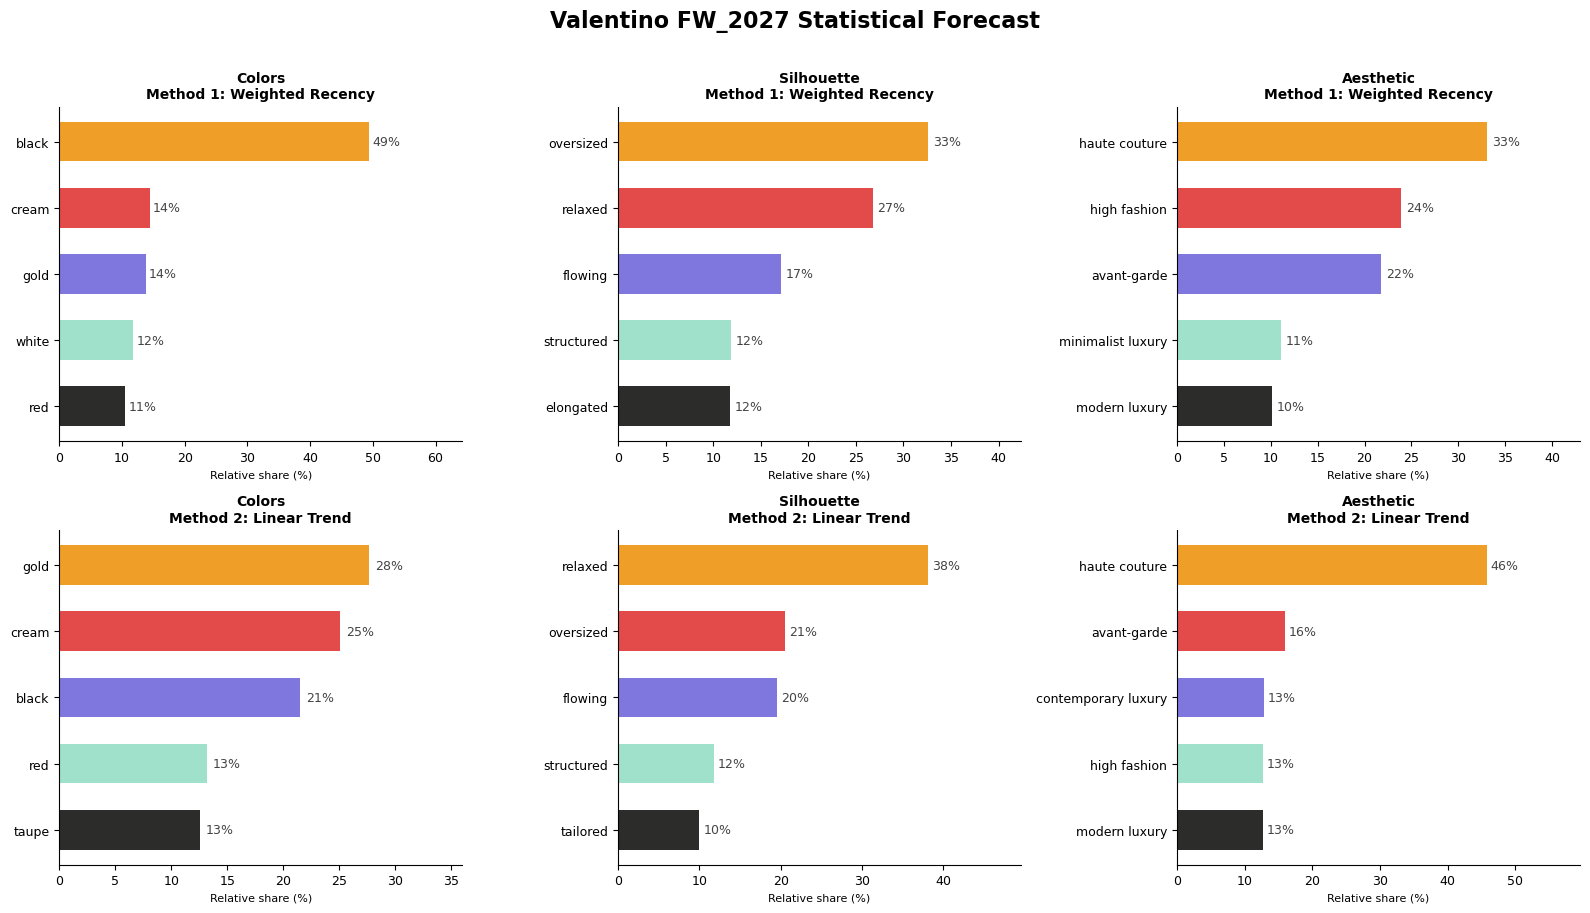

In [47]:
#Creating a summary and chart for the FW statistical forecast:

def print_clean_forecast(label, colors, silhouettes, aesthetics):
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Colors:      {', '.join([v for v,_ in colors])}")
    print(f"  Silhouette:  {', '.join([v for v,_ in silhouettes])}")
    print(f"  Aesthetic:   {', '.join([v for v,_ in aesthetics])}")

print_clean_forecast("METHOD 1: Weighted Recency", wr_colors_fw, wr_silhouettes_fw, wr_aesthetics_fw)
print_clean_forecast("METHOD 2: Linear Trend Projection", lt_colors_fw, lt_silhouettes_fw, lt_aesthetics_fw)



#now here's a chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Valentino FW_2027 Statistical Forecast", fontsize=16, fontweight='bold', y=1.01)

categories = [
    ("Colors",     wr_colors_fw,     lt_colors_fw),
    ("Silhouette", wr_silhouettes_fw, lt_silhouettes_fw),
    ("Aesthetic",  wr_aesthetics_fw,  lt_aesthetics_fw),
]

method_titles = ["Method 1: Weighted Recency", "Method 2: Linear Trend"]
colors_wr = ["#1a1a1a", "#f5f0e8", "#c9a84c", "#ffffff", "#cc2200"]
bar_colors = ["#2C2C2A", "#9FE1CB", "#7F77DD", "#E24B4A", "#EF9F27"]

for col, (cat_name, wr_data, lt_data) in enumerate(categories):
    for row, (data, title) in enumerate([(wr_data, method_titles[0]), (lt_data, method_titles[1])]):
        ax = axes[row][col]
        labels = [v for v, _ in data]
        values = [s for _, s in data]
        
        # Normalize to percentages for readability
        total = sum(values)
        pcts = [v / total * 100 for v in values]
        
        bars = ax.barh(labels[::-1], pcts[::-1], color=bar_colors[:len(labels)], 
                       edgecolor='none', height=0.6)
        
        # Add percentage labels on bars
        for bar, pct in zip(bars, pcts[::-1]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{pct:.0f}%', va='center', fontsize=9, color='#444')
        
        ax.set_title(f"{cat_name}\n{title}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Relative share (%)", fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=9)
        ax.set_xlim(0, max(pcts) * 1.3)

plt.tight_layout()
plt.savefig('outputs/statistical_forecast_fw.png', dpi=150, bbox_inches='tight')
plt.show()


In [45]:
#Again I'm just using the same code as above but using it for FW instead of SS
# Prompt A: from Claude forecast (already narrative, just needs a clean prompt extracted). 
prompt_a_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[{
        "role": "user",
        "content": f"""Based on this fashion forecast for Valentino FW_2027, write a single detailed 
image generation prompt (3-4 sentences) that describes one representative runway look. 
Be specific about garment construction, colors, fabrics, silhouette, styling details, and mood.
Write it as a direct visual description, not as an instruction. Important: The prompt must describe fully clothed looks only. 
Focus on garment construction, tailoring, and fabric details. 
Do not reference exposed skin, bare torsos, or revealing styling. Use the words taupe or beige to describe the color nude.""

Forecast:
{claude_forecast_fw}"""
    }]
)
image_prompt_claude_fw = prompt_a_message.content[0].text
print("=== IMAGE PROMPT FROM CLAUDE FORECAST ===")
print(image_prompt_claude_fw)

# Prompt B: from statistical forecast
stat_summary = f"""
Top predicted colors: {', '.join([v for v,_ in wr_colors])}
Top predicted silhouettes: {', '.join([v for v,_ in wr_silhouettes])}
Top predicted aesthetics: {', '.join([v for v,_ in wr_aesthetics])}
Rising trends (linear projection): 
  colors: {', '.join([v for v,_ in lt_colors[:3]])}
  silhouettes: {', '.join([v for v,_ in lt_silhouettes[:3]])}
  aesthetics: {', '.join([v for v,_ in lt_aesthetics[:3]])}
"""

prompt_b_message = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[{
        "role": "user",
        "content": f"""Based on this statistical forecast for Valentino FW_2027, write a single detailed 
image generation prompt (3-4 sentences) that describes one representative runway look.
Be specific about garment construction, colors, fabrics, silhouette, styling details, and mood.
Write it as a direct visual description, not as an instruction. Important: The prompt must describe fully clothed looks only. 
Focus on garment construction, tailoring, and fabric details. 
Do not reference exposed skin, bare torsos, or revealing styling. Use the words taupe or beige to describe the color nude""

Statistical forecast:
{statistical_forecast_fw}"""
    }]
)
image_prompt_statistical_fw = prompt_b_message.content[0].text
print("\n=== IMAGE PROMPT FROM STATISTICAL FORECAST ===")
print(image_prompt_statistical)

# --- STEP 2: Generate images with DALL-E 3 ---

def generate_and_save(prompt, filename):
    print(f"\nGenerating: {filename}...")
    
    response = openai_client.images.generate(
        model="dall-e-3",
        prompt=f"High fashion runway photography. {prompt} Shot on a clean white runway, professional editorial lighting.",
        size="1024x1024",
        quality="standard",
        n=1,
    )
    
    image_url = response.data[0].url
    
    # Download and save the image
    image_data = requests.get(image_url).content
    save_path = f"outputs/{filename}"
    with open(save_path, "wb") as f:
        f.write(image_data)
    
    print(f"✓ Saved to {save_path}")
    return save_path

# Generate both images
path_claude = generate_and_save(image_prompt_claude_fw, "forecast_claude_fw2027.png")
path_statistical = generate_and_save(image_prompt_statistical_fw, "forecast_statistical_fw2027.png")

print("\n✓ Both images generated and saved!")

=== IMAGE PROMPT FROM CLAUDE FORECAST ===
# Valentino FW_2027 Runway Look

A voluminous curved cocoon coat in double-faced cashmere extends to mid-calf, crafted in rich black on the exterior with a taupe reverse visible at the rolled collar and sleeve cuffs, featuring rounded architectural shoulders and concealed snap closures finished with brushed gold hardware. Beneath, a relaxed tailored trouser in cream bonded wool-silk sits high on the waist with generous volume through the hip that tapers sharply at the ankle, paired with an elongated unstructured blazer in camel brushed mohair with sleeves deliberately pushed to the elbow. The styling embodies refined volume through masterful construction—ease without slouch, luxury without embellishment—creating a sophisticated mood of languid modernism where architectural precision meets organic movement, grounded in Valentino's signature dark-neutral foundation now warmed by emerging earth tones and elevated by gold as a core neutral rather t